# Biomarcador 1 - Latencia de Arranque

In [64]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from routines import rellenar_muestras

plt.rcParams["figure.figsize"] = (20,6)

df = pd.read_parquet("/Users/idertator/20250516_181320.parquet")
df

,timestamp,stimuli_x,stimuli_y,stimuli_color,eyes_x,eyes_y,key
0,1747411972293,0,0,16777215,0,0,0
1,1747411972345,0,0,16777215,893,391,0
2,1747411972350,0,0,16777215,893,391,0
3,1747411972367,0,0,16777215,893,391,0
4,1747411972384,0,0,16777215,893,391,0
...,...,...,...,...,...,...,...
1664,1747412000524,31,169,255,24,166,0
1665,1747412000542,31,169,255,24,166,0
1666,1747412000557,31,169,255,24,166,0
1667,1747412000575,31,169,255,24,166,0


## Rutinas

In [123]:
import numpy as np
from scipy.signal import convolve, find_peaks

def distance(x, y):
    """
    Calcula la distancia entre dos puntos en un espacio 2D (vector desplazamiento).

    Args:
        x (ndarray): Coordenadas x de los puntos.
        y (ndarray): Coordenadas y de los puntos.

    Returns:
        ndarray: Distancia entre los puntos.
    """
    x_prev = x[:-1].astype(np.int32)
    x_curr = x[1:].astype(np.int32)
    y_prev = y[:-1].astype(np.int32)
    y_curr = y[1:].astype(np.int32)
    return np.sqrt((x_prev - x_curr) ** 2 + (y_prev - y_curr) ** 2)


def differentiate(channel: np.ndarray):
    window = np.array([300, -294, -532, -503, -296, 0, 296, 503, 532, 294, -300])
    result = convolve(channel, window, "same") / 5148.0
    result[:5] = 0
    result[-5:] = 0
    return result * 1000


def starts(abs_velocity, peaks, threshold=0.5):
    """
    Encuentra los índices de inicio de los picos de velocidad.

    Args:
        abs_velocity (ndarray): Perfil de velocidad absoluto.
        peaks (list[int]): Índices de los picos detectados.
        threshold (float): Umbral mínimo para considerar un pico.

    Returns:
        list[int]: Índices de inicio de los picos detectados.
    """
    start_indices = []
    for peak in peaks:
        for i in range(peak, 0, -1):
            if abs_velocity[i] < threshold and abs_velocity[i + 1] > threshold:
                start_indices.append(i + 1)
                break
        else:
            start_indices.append(0)
    return start_indices


def start_latency(df, threshold=0.5, ventana=600):
    """
    Calcula la latencia de arranque a partir de un DataFrame.

    Args:
        df (pd.DataFrame): DataFrame con columnas 'ts', 'sx', 'sy', 'ex', 'ey'.
        threshold (float): Umbral mínimo para considerar un pico.
        ventana (int): Tamaño de la ventana para el cálculo de la velocidad.

    Returns:
        list[int]: Lista de latencias de arranque.
    """

    latencias = []
    df = df.reset_index(drop=True)
    df["stimuli_change"] = (df["stimuli_x"].diff() != 0) | (df["stimuli_y"].diff() != 0)

    for i in range(1, len(df)):
        if df.loc[i, "stimuli_change"] and i + ventana <= len(df):
            ts_cambio = df.loc[i, "timestamp"]
            ventana_df = df.iloc[i : i + ventana]

            ex = ventana_df["eyes_x"].values
            ey = ventana_df["eyes_y"].values
            ts = ventana_df["timestamp"].values

            vx = differentiate(ex)
            vy = differentiate(ey)
            vel = np.sqrt(vx**2 + vy**2)
            abs_vel = np.abs(vel)

            peaks = velocity_peaks(abs_vel, threshold)
            print("Picos:", peaks)

            if not peaks:
                latencias.append(None)
                continue

            inicios = starts(abs_vel, peaks, threshold)
            ts_inicio = ts[inicios[0]]
            latencias.append(int(ts_inicio - ts_cambio))

    return latencias

rellenado = rellenar_muestras(df)

latencias = start_latency(rellenado, threshold=0.1, ventana=600)
print("Latencia detectada:", latencias)

Picos: [115, 119, 124, 166, 170, 175, 301, 305, 310, 334, 338, 343, 351, 355, 360, 367, 371, 376, 385, 389, 394, 401, 405, 410, 418, 422, 427, 435, 439, 444, 452, 456, 461, 470, 474, 479, 486, 490, 495, 504, 508, 513, 521, 525, 530, 538, 542, 547, 555, 559, 564, 571, 575, 580, 589, 593]
Picos: [451, 455, 460, 469, 473, 478, 486, 490, 495, 503, 507, 512, 519, 523, 528, 536, 540, 545, 552, 556, 561, 569, 573, 578, 587, 591]
Picos: [349, 353, 358, 365, 369, 374, 382, 386, 391, 399, 403, 408, 416, 420, 425, 432, 436, 441, 448, 452, 457, 466, 470, 475, 482, 486, 491, 500, 504, 509, 517, 521, 526, 534, 538, 543, 569, 573, 578, 585, 589, 594]
Picos: [363, 367, 372, 377, 381, 386, 396, 400, 405, 411, 415, 420, 428, 432, 437, 446, 450, 455, 462, 466, 471, 479, 483, 488, 497, 501, 506, 513, 517, 522, 529, 533, 538, 547, 551, 556, 564, 568, 573, 581, 585, 590]
Picos: [488, 492, 497, 503, 507, 512, 522, 526, 531, 538, 542, 547, 554, 558, 563, 570, 574, 579, 587, 591]
Picos: [401, 405, 410, 417, 42

In [13]:
rellenado

,timestamp,stimuli_x,stimuli_y,stimuli_color,eyes_x,eyes_y,key
0,1747411972293,0,0,16777215,0,0,0
1,1747411972294,0,0,16777215,0,0,0
2,1747411972295,0,0,16777215,0,0,0
3,1747411972296,0,0,16777215,0,0,0
4,1747411972297,0,0,16777215,0,0,0
...,...,...,...,...,...,...,...
28295,1747412000588,31,169,255,24,166,0
28296,1747412000589,31,169,255,24,166,0
28297,1747412000590,31,169,255,24,166,0
28298,1747412000591,31,169,255,24,166,0


In [50]:
rellenado = rellenar_muestras(df)

distance_e = distance(rellenado["eyes_x"], rellenado["eyes_y"])

time = rellenado["timestamp"][1:-1]
distance_e = distance_e.values[1:-1]


array([], dtype=float64)

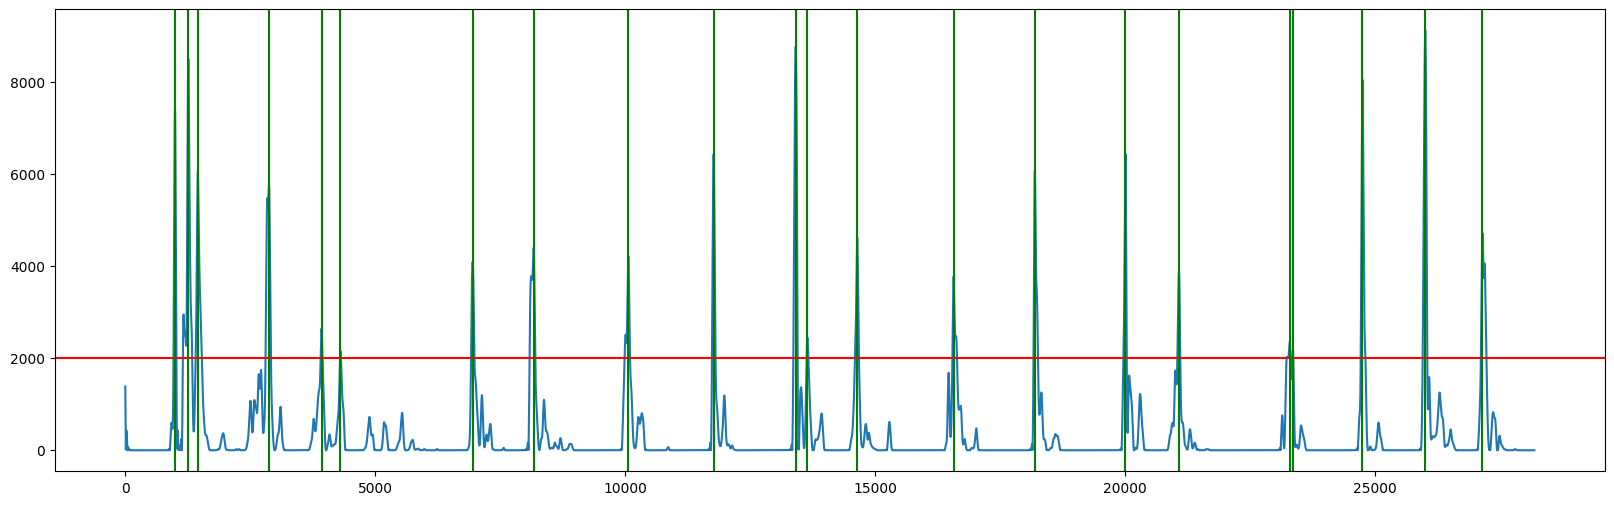

In [122]:
from scipy import signal
from typing import Iterator

def denoise_35(channel: np.ndarray) -> np.ndarray:
    """Remove high frequency noise from the channel

    Args:
        channel (ndarray): Channel

    Returns:
        ndarray: Channel
    """
    # Hacemos un filtrado agresivo ya que lo que nos interesa es la forma de onda
    # en general de la señal para identificar el desfase
    b, a = signal.butter(3, 0.035)
    y = signal.filtfilt(b, a, channel)
    return y


def find_peaks(vel: np.ndarray, threshold: float) -> Iterator[int]:
    max_idx = None
    max_value = None
    for idx, sample in enumerate(vel):
        if sample < threshold:
            if max_idx is not None:
                yield max_idx
                
            max_idx = None
            max_value = None
            continue

        if max_idx is None or sample > max_value:
            max_idx = idx
            max_value = sample

    if max_idx is not None:
        yield max_idx


    
from scipy.signal import medfilt
THRESHOLD = 2000
START = 100
END = rellenado.shape[0]

eyes_x = rellenado["eyes_x"].values.astype(np.int32)
eyes_y = rellenado["eyes_y"].values.astype(np.int32)

dis = distance(eyes_x, eyes_y)[1:-1]
vel = abs(differentiate(dis))
# vel = medfilt(vel, 31)
vel = abs(denoise_35(vel))
peaks = list(find_peaks(vel, threshold=THRESHOLD))

plt.plot(vel[START:END])
plt.axhline(THRESHOLD, color="r")
for peak in peaks:
    p = peak - START
    if p < 0 or p > END:
        continue
    plt.axvline(p, color='g')


In [56]:
rellenado[40:60]

,timestamp,stimuli_x,stimuli_y,stimuli_color,eyes_x,eyes_y,key
40,1747411972333,0,0,16777215,0,0,0
41,1747411972334,0,0,16777215,0,0,0
42,1747411972335,0,0,16777215,0,0,0
43,1747411972336,0,0,16777215,0,0,0
44,1747411972337,0,0,16777215,0,0,0
45,1747411972338,0,0,16777215,0,0,0
46,1747411972339,0,0,16777215,0,0,0
47,1747411972340,0,0,16777215,0,0,0
48,1747411972341,0,0,16777215,0,0,0
49,1747411972342,0,0,16777215,0,0,0
